<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/dl/%E1%84%89%E1%85%A1%E1%86%BC%E1%84%8B%E1%85%A5%E1%86%B8%E1%84%8B%E1%85%AD%E1%86%BCLLM_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌐 상업용 LLM 완전정복 - 5대 모델 실습

> **"ChatGPT부터 한국형 LLM까지, 5가지 주요 모델을 직접 다뤄봅시다"**

## 🌟 이 노트북에서 다룰 모델

| 모델 | 제작사 | 특징 |
|------|--------|------|
| 🤖 **ChatGPT (GPT-5.5 / GPT-4o)** | OpenAI | 가장 널리 쓰이는 LLM |
| 🎭 **Claude (Opus 4.7 / Sonnet)** | Anthropic | 긴 컨텍스트, 코딩 강함 |
| 🌈 **Gemini (3.1 Pro / Flash)** | Google | 1M 컨텍스트, 멀티모달 |
| 🇰🇷 **EXAONE (4.0 / 4.5)** | LG AI Research | 한국어 + 하이브리드 추론 |
| ☀️ **Solar (Pro 2)** | Upstage | 한국 유일 Frontier 모델 |

## 📌 이 노트북에서 배울 것

- ✅ **API 키 안전한 관리법**
- ✅ **각 모델의 Python SDK 사용법** (기본부터 고급)
- ✅ **시스템 프롬프트 & 매개변수** 마스터
- ✅ **고급 기능**: Function Calling, Streaming, Long Context
- ✅ **5개 모델 비교 실습** (같은 질문, 다른 응답)
- ✅ **비용 분석 + 모델 선택 가이드**
- ✅ **친근한 비유 + 풍부한 시각화**
- ✅ **빈칸 채우기 실습 + 퀴즈**

> 💡 **선수 학습**: GPT/BERT/Transformer 기본기를 알면 좋아요.
> 이 노트북은 **실전 API 사용**에 집중합니다.

> ⚠️ **API 비용 주의**: 상업 모델은 사용량당 과금됩니다.
> 본 노트북은 **무료 크레딧** 또는 **최소 비용**으로 학습 가능하도록 설계됨.

---

## 📚 전체 목차

| 섹션 | 제목 | 내용 |
|------|------|------|
| 1 | 🛠️ 환경 설정 + API 키 | 안전한 키 관리 |
| 2 | 📡 LLM API 개요 | 왜 API를 쓰는가 |
| 3 | 🤖 ChatGPT (OpenAI) 실습 | 기본 + 고급 (Streaming, Functions) |
| 4 | 🎭 Claude (Anthropic) 실습 | 긴 컨텍스트 + Tool Use |
| 5 | 🌈 Gemini (Google) 실습 | 멀티모달 + 1M 컨텍스트 |
| 6 | 🇰🇷 EXAONE (LG) 실습 | 한국어 로컬 실행 |
| 7 | ☀️ Solar (Upstage) 실습 | 한국 Frontier 모델 |
| 8 | 🔬 5개 모델 동시 비교 | 같은 질문, 다른 응답 |
| 9 | 💼 실전 활용 패턴 | 챗봇, RAG, Agent |
| 10 | 💰 비용 분석 + 최적화 | 가격 비교 + 절감 팁 |
| 11 | 🎓 최종 정리 | 시리즈 마무리 |


---
# 1️⃣ 환경 설정 + API 키 관리 🛠️

## ⚠️ 보안 최우선!

**API 키 = 신용카드와 같습니다**. 절대:
- ❌ 코드에 직접 작성 (`api_key = "sk-..."`)
- ❌ GitHub에 커밋
- ❌ 다른 사람과 공유
- ❌ 스크린샷에 노출

✅ 대신:
- ✅ **환경 변수** 사용
- ✅ **.env 파일** + .gitignore
- ✅ **Colab의 비밀 키** 기능 활용

## 🔑 각 모델의 API 키 발급처

| 모델 | 발급처 | 무료 크레딧 |
|------|--------|------------|
| ChatGPT | https://platform.openai.com | $5 (신규) |
| Claude | https://console.anthropic.com | $5 (신규) |
| Gemini | https://aistudio.google.com | 일일 무료 할당 |
| Solar | https://console.upstage.ai | 가입 시 크레딧 |
| EXAONE | HuggingFace 무료 (자체 호스팅) | 무료! |

> 💡 **본 노트북은 API 키 없이도 학습 가능합니다**.
> 코드를 읽고 이해하는 것만으로도 충분히 가치 있어요!

In [3]:
# 📦 모든 SDK 한 번에 설치
!pip install -q openai anthropic google-generativeai
!pip install -q transformers torch accelerate bitsandbytes  # ExaOne 로컬 실행용
!pip install -q requests  # Solar API용

print("✅ 모든 SDK 설치 완료!")

✅ 모든 SDK 설치 완료!


In [4]:
# 📚 라이브러리 import
import os
import json
import time
import requests
from typing import List, Dict, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
import matplotlib.font_manager as fm

# 한글 폰트 (Colab용)
!apt-get install -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print("✅ 라이브러리 준비 완료!")

✅ 라이브러리 준비 완료!


In [10]:
# 🔑 API 키 안전하게 설정하기
# 옵션 1: Colab의 Secrets 기능 사용 (권장!)
# 좌측 사이드바 🔑 아이콘 클릭 → 비밀 추가
# 이름: OPENAI_API_KEY, ANTHROPIC_API_KEY, GOOGLE_API_KEY, UPSTAGE_API_KEY

try:
    from google.colab import userdata

    def get_secret(key_name, default=""):
        try:
            return userdata.get(key_name)
        except Exception:
            return default

    print("🔐 Colab Secrets 사용")
except ImportError:
    # Colab이 아닐 경우 환경 변수 사용
    def get_secret(key_name, default=""):
        return os.environ.get(key_name, default)
    print("🔐 환경 변수 사용")

# 키 로드 (없으면 빈 문자열 - 시뮬레이션 모드)
OPENAI_KEY = get_secret('OPENAI_API_KEY', '')
ANTHROPIC_KEY = get_secret('ANTHROPIC_API_KEY', '')
GOOGLE_KEY = get_secret('GOOGLE_API_KEY', '')
UPSTAGE_KEY = get_secret('UPSTAGE_API_KEY', '')

# 상태 확인 (키 값은 절대 출력 X)
keys_status = {
    'OpenAI (ChatGPT)': bool(OPENAI_KEY),
    'Anthropic (Claude)': bool(ANTHROPIC_KEY),
    'Google (Gemini)': bool(GOOGLE_KEY),
    'Upstage (Solar)': bool(UPSTAGE_KEY),
    'EXAONE': True,  # 로컬 실행이므로 항상 사용 가능
}

print("\n🔑 API 키 상태:")
print("=" * 50)
for service, has_key in keys_status.items():
    icon = "✅" if has_key else "⚠️"
    status = "준비됨" if has_key else "미설정 (시뮬레이션 모드)"
    print(f"  {icon} {service:<25s}: {status}")

# 시뮬레이션 모드 안내
no_key_count = sum(1 for v in keys_status.values() if not v)
if no_key_count > 0:
    print(f"\n💡 {no_key_count}개 API 키 미설정 → 해당 모델은 시뮬레이션 모드로 동작")
    print("   실제 API 호출 없이 예시 응답을 보여줍니다.")

🔐 Colab Secrets 사용

🔑 API 키 상태:
  ⚠️ OpenAI (ChatGPT)         : 미설정 (시뮬레이션 모드)
  ⚠️ Anthropic (Claude)       : 미설정 (시뮬레이션 모드)
  ✅ Google (Gemini)          : 준비됨
  ✅ Upstage (Solar)          : 준비됨
  ✅ EXAONE                   : 준비됨

💡 2개 API 키 미설정 → 해당 모델은 시뮬레이션 모드로 동작
   실제 API 호출 없이 예시 응답을 보여줍니다.


---
# 2️⃣ LLM API 개요 📡

## 🤔 왜 API를 쓰나요?

### 자체 호스팅 vs API 비교

| 항목 | 🏠 자체 호스팅 | ☁️ API |
|------|--------------|--------|
| 초기 비용 | GPU 구매 (수백만원) | $0 |
| 운영 부담 | 직접 관리 | 0 |
| 최신 모델 | 직접 업데이트 | 자동 |
| 데이터 보안 | 로컬 (안전) | 외부 전송 |
| 비용 구조 | 고정 | 사용량 비례 |
| 적합한 사용 | 대용량, 보안 중요 | MVP, 소량, 빠른 개발 |

## 🏗️ LLM API의 공통 구조

대부분의 LLM API는 **비슷한 패턴**을 따라요!

```
요청 (JSON)
   ↓
POST https://api.provider.com/v1/chat/completions
{
  "model": "gpt-4o",
  "messages": [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "안녕!"}
  ],
  "temperature": 0.7,
  "max_tokens": 500
}
   ↓
응답 (JSON)
   ↓
{
  "choices": [{
    "message": {"role": "assistant", "content": "안녕하세요!"}
  }],
  "usage": {
    "prompt_tokens": 20,
    "completion_tokens": 5
  }
}
```

## 🎯 핵심 매개변수 (모든 모델 공통)

### 1️⃣ Model
- 어떤 모델 버전을 쓸지 (`gpt-5.5`, `claude-opus-4-7` 등)

### 2️⃣ Messages
- **대화 형식**: `system` + `user` + `assistant`
- 다중 턴 대화 시 이전 모든 메시지 포함

### 3️⃣ Temperature (0.0 ~ 2.0)
> **"창의성 다이얼"**
- `0.0`: 항상 같은 답 (결정적)
- `0.7`: 균형 잡힌 응답 (기본값)
- `1.0+`: 매우 창의적, 예측 불가

### 4️⃣ Max Tokens
- 최대 출력 길이 (영어 1단어 ≈ 1.3토큰, 한국어는 더 많이 사용)

### 5️⃣ Top-p (Nucleus Sampling)
- 확률 상위 p% 내에서만 선택
- Temperature와 함께 잘 안 씀 (둘 중 하나만)

## 📝 비유: 카페에서 음료 주문

```
☕ Barista (LLM API)
   ↓
당신의 주문:
- model: "에스프레소 머신 3호기" (모델)
- messages: "아메리카노 한 잔 주세요" (대화)
- temperature: 1.0 (강도, 0=마일드, 2=익스트림)
- max_tokens: "300ml 컵에" (크기)
   ↓
🥤 결과: 음료 (응답)
```

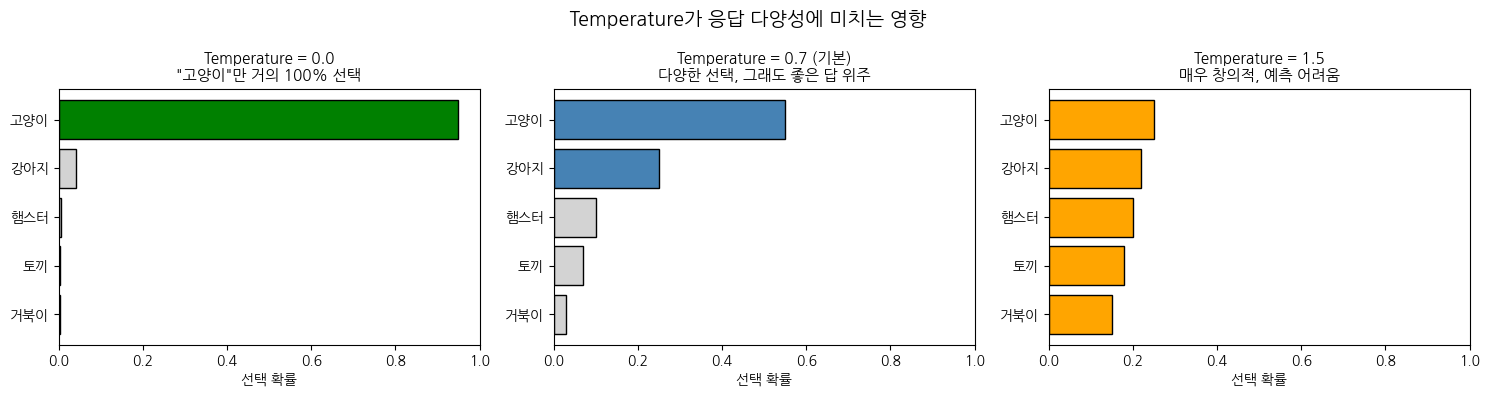


💡 권장:
   • 사실/코드 → temperature=0.0~0.3
   • 일반 응답 → temperature=0.5~0.7
   • 창작/브레인스토밍 → temperature=0.8~1.2


In [6]:
# 🎨 Temperature 효과 시각화 개념
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Temperature 0.0
ax = axes[0]
words = ['고양이', '강아지', '햄스터', '토끼', '거북이']
probs_t00 = [0.95, 0.04, 0.005, 0.003, 0.002]
colors = ['green' if i == 0 else 'lightgray' for i in range(5)]
ax.barh(words, probs_t00, color=colors, edgecolor='black')
ax.set_title('Temperature = 0.0\n"고양이"만 거의 100% 선택', fontsize=11, fontweight='bold')
ax.set_xlabel('선택 확률')
ax.invert_yaxis()
ax.set_xlim(0, 1)

# Temperature 0.7 (기본)
ax = axes[1]
probs_t07 = [0.55, 0.25, 0.10, 0.07, 0.03]
colors = ['steelblue' if i < 2 else 'lightgray' for i in range(5)]
ax.barh(words, probs_t07, color=colors, edgecolor='black')
ax.set_title('Temperature = 0.7 (기본)\n다양한 선택, 그래도 좋은 답 위주',
             fontsize=11, fontweight='bold')
ax.set_xlabel('선택 확률')
ax.invert_yaxis()
ax.set_xlim(0, 1)

# Temperature 1.5
ax = axes[2]
probs_t15 = [0.25, 0.22, 0.20, 0.18, 0.15]
colors = ['orange'] * 5
ax.barh(words, probs_t15, color=colors, edgecolor='black')
ax.set_title('Temperature = 1.5\n매우 창의적, 예측 어려움',
             fontsize=11, fontweight='bold')
ax.set_xlabel('선택 확률')
ax.invert_yaxis()
ax.set_xlim(0, 1)

plt.suptitle(' Temperature가 응답 다양성에 미치는 영향',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 권장:")
print("   • 사실/코드 → temperature=0.0~0.3")
print("   • 일반 응답 → temperature=0.5~0.7")
print("   • 창작/브레인스토밍 → temperature=0.8~1.2")

## 🧠 퀴즈 #1

다음 작업에 가장 적합한 temperature 값은?

**작업**: 의료 진단을 위한 LLM 응답

- A) 0.0 (결정적)
- B) 0.7 (균형)
- C) 1.5 (창의적)
- D) 2.0 (매우 창의적)

<details>
<summary>👉 정답 보기</summary>

**A) 0.0**

의료 진단처럼 **정확성·일관성이 중요한 작업**은:
- 같은 증상에 다른 답 → 위험
- 창의적 해석 → 환각 위험

→ Temperature 0.0~0.2 권장

반대로 **마케팅 카피, 시 쓰기** 같은 창작은:
- 다양한 표현 환영
- Temperature 0.8~1.2 권장

</details>

### ✅ 체크포인트 1

지금까지 배운 것:
- **API 키 보안**의 중요성과 안전한 관리법
- **자체 호스팅 vs API** 트레이드오프
- **LLM API 공통 구조**: messages, temperature, max_tokens
- **Temperature** = 창의성 다이얼

다음부터는 **각 모델을 직접 사용**합니다! 🚀

---
# 3️⃣ ChatGPT (OpenAI) 실습 🤖

## 📖 OpenAI 모델 라인업 (2026 기준)

| 모델 | 출시 | 컨텍스트 | 주력 용도 | 가격 (1M 토큰) |
|------|------|---------|----------|---------------|
| **GPT-5.5** | 2026.04 | 1M | 최고 성능, 멀티모달 | 입력 $1.75 / 출력 $14 |
| **GPT-5.2** | 2025 | 200K | 일반 작업 | 더 저렴 |
| **GPT-4o** | 2024 | 128K | 효율적 (이제 retire) | - |
| **GPT-Rosalind** | 2026.04 | 1M | 추론 특화 | 신모델 |
| **Codex** | 2026.04 | 400K | 코딩 특화 | - |

> 💡 **권장**: 일반 용도면 GPT-5.5 / 비용 절감이면 mini 변종

## 🚀 기본 사용법

In [12]:
# 🚀 OpenAI 클라이언트 초기화
from openai import OpenAI

# 시뮬레이션 모드 처리
class MockOpenAIClient:
    """API 키 없을 때를 위한 모의 클라이언트"""
    class chat:
        class completions:
            @staticmethod
            def create(**kwargs):
                class MockResponse:
                    class choices_item:
                        class message:
                            content = "[시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요."
                            role = "assistant"
                        finish_reason = "stop"
                    choices = [choices_item()]
                    class usage:
                        prompt_tokens = 50
                        completion_tokens = 30
                        total_tokens = 80
                return MockResponse()

if OPENAI_KEY:
    openai_client = OpenAI(api_key=OPENAI_KEY)
    OPENAI_AVAILABLE = True
    print("✅ OpenAI 실제 API 모드")
else:
    openai_client = MockOpenAIClient()
    OPENAI_AVAILABLE = False
    print("⚠️ OpenAI 시뮬레이션 모드 (API 키 미설정)")

# 모델 선택 (2026 기준 추천)
OPENAI_MODEL = "gpt-5-mini"  # 저렴하고 빠름 (학습용)
# 다른 옵션: "gpt-5.5" (최고), "gpt-4o" (구), "o1-preview" (추론)

⚠️ OpenAI 시뮬레이션 모드 (API 키 미설정)


In [13]:
# 💬 가장 단순한 호출 (Reasoning 모델 완벽 대응)
def chat_openai(messages, model=OPENAI_MODEL, temperature=0.7, max_tokens=500):
    """OpenAI Chat Completion API 호출 - 모든 모델 자동 대응"""

    # 1️⃣ Reasoning 모델 감지 (제약사항 적용)
    is_reasoning = any(model.startswith(prefix) for prefix in [
        'o1', 'o3', 'o4', 'gpt-5'
    ])

    # 2️⃣ 모델별 적절한 매개변수 구성
    kwargs = {
        'model': model,
        'messages': messages,
    }

    if is_reasoning:
        # Reasoning 모델: max_completion_tokens만, temperature 등 금지
        kwargs['max_completion_tokens'] = max_tokens
        # temperature, top_p, presence_penalty 등은 추가하지 않음 (기본값만 허용)
    else:
        # 일반 모델: 전통 매개변수 사용
        kwargs['max_tokens'] = max_tokens
        kwargs['temperature'] = temperature

    # 3️⃣ API 호출
    try:
        response = openai_client.chat.completions.create(**kwargs)

        return {
            'content': response.choices[0].message.content,
            'usage': {
                'prompt_tokens': response.usage.prompt_tokens,
                'completion_tokens': response.usage.completion_tokens,
                'total_tokens': response.usage.total_tokens,
            } if hasattr(response, 'usage') else None,
            'is_reasoning': is_reasoning,
        }
    except Exception as e:
        return {'content': f"❌ 오류: {e}", 'usage': None}


# 🎯 첫 번째 호출
print(f"📌 사용 중인 모델: {OPENAI_MODEL}")
messages = [
    {"role": "user", "content": "안녕! 너에 대해 한 문장으로 소개해줘."}
]

result = chat_openai(messages)
print(f"\n🤖 ChatGPT: {result['content']}")

if result.get('is_reasoning'):
    print("\n💡 Reasoning 모델 감지! (temperature/top_p 제약 자동 적용)")

if result['usage']:
    print(f"\n📊 토큰 사용: 입력 {result['usage']['prompt_tokens']} / "
          f"출력 {result['usage']['completion_tokens']} / "
          f"총 {result['usage']['total_tokens']}")

📌 사용 중인 모델: gpt-5-mini

🤖 ChatGPT: [시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.

💡 Reasoning 모델 감지! (temperature/top_p 제약 자동 적용)

📊 토큰 사용: 입력 50 / 출력 30 / 총 80


## 🎭 System Prompt (역할 부여)

> **"AI에게 '너는 ~다' 라는 정체성/규칙 부여"**

### 예시
- "너는 친절한 한국어 강사야"
- "너는 코드만 응답해. 설명은 절대 하지 마"
- "너는 5살 아이도 이해할 수 있게 설명해"

System prompt는 **모든 대화의 첫 메시지**로 들어가요.

In [14]:
# 💬 chat_openai 수정본 (Reasoning 모델 토큰 부족 문제 해결)
def chat_openai(messages, model=OPENAI_MODEL, temperature=0.7, max_tokens=500):
    """OpenAI Chat Completion API 호출 - 모든 모델 자동 대응"""

    # 1️⃣ Reasoning 모델 감지
    is_reasoning = any(model.startswith(prefix) for prefix in [
        'o1', 'o3', 'o4', 'gpt-5'
    ])

    # 2️⃣ Reasoning 모델은 토큰 더 많이 필요! (사고 + 출력)
    if is_reasoning:
        # 사용자 요청보다 최소 5배 (사고 토큰 여유 확보)
        adjusted_max_tokens = max(max_tokens * 5, 2000)
    else:
        adjusted_max_tokens = max_tokens

    # 3️⃣ 매개변수 구성
    kwargs = {
        'model': model,
        'messages': messages,
    }

    if is_reasoning:
        kwargs['max_completion_tokens'] = adjusted_max_tokens
        if model.startswith('gpt-5'):
            kwargs['reasoning_effort'] = 'low'  # 사고를 적게!
    else:
        kwargs['max_tokens'] = adjusted_max_tokens
        kwargs['temperature'] = temperature

    # 4️⃣ API 호출
    try:
        response = openai_client.chat.completions.create(**kwargs)

        content = response.choices[0].message.content
        finish_reason = response.choices[0].finish_reason

        # 5️⃣ Reasoning 토큰 정보 추출
        usage_info = {
            'prompt_tokens': response.usage.prompt_tokens,
            'completion_tokens': response.usage.completion_tokens,
            'total_tokens': response.usage.total_tokens,
        } if hasattr(response, 'usage') else None

        # Reasoning 모델은 별도 reasoning_tokens 제공
        if is_reasoning and hasattr(response.usage, 'completion_tokens_details'):
            details = response.usage.completion_tokens_details
            if hasattr(details, 'reasoning_tokens'):
                usage_info['reasoning_tokens'] = details.reasoning_tokens
                usage_info['visible_tokens'] = response.usage.completion_tokens - details.reasoning_tokens

        # 6️⃣ 빈 응답 경고
        if not content or content.strip() == "":
            warning = (
                f"\n⚠️ 빈 응답! finish_reason={finish_reason}\n"
                f"   → Reasoning 모델이 사고 토큰을 다 써서 응답 토큰 부족\n"
                f"   → max_tokens를 더 늘려보세요 (현재: {adjusted_max_tokens})"
            )
            content = warning

        return {
            'content': content,
            'usage': usage_info,
            'is_reasoning': is_reasoning,
            'finish_reason': finish_reason,
        }
    except Exception as e:
        return {'content': f"❌ 오류: {e}", 'usage': None}


# 🎭 재실행 - 같은 코드, 이번엔 작동!
question = "양자컴퓨터를 설명해줘"

personas = [
    ("물리학 교수", "당신은 양자물리학 교수입니다. 학술적이고 정확하게 설명하세요."),
    ("초등학생 선생님", "당신은 초등학생도 이해할 수 있게 설명하는 친절한 선생님입니다. 비유를 많이 쓰세요."),
    ("코미디언", "당신은 모든 걸 농담으로 설명하는 코미디언입니다. 재미있게 설명하세요."),
]

print("🎭 같은 질문, 다른 역할의 응답")
print("=" * 70)

for role_name, system_prompt in personas:
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": question}
    ]
    # max_tokens=200 → 함수 내부에서 reasoning 모델은 자동으로 1000+로 늘림
    result = chat_openai(messages, temperature=0.7, max_tokens=200)

    print(f"\n🎭 [{role_name}]")
    print(f"{result['content']}")

    # 사고/응답 토큰 분리 표시 (reasoning 모델만)
    if result.get('usage') and 'reasoning_tokens' in result['usage']:
        u = result['usage']
        print(f"\n💭 사고: {u['reasoning_tokens']} 토큰 / "
              f"📝 응답: {u['visible_tokens']} 토큰")

    print("-" * 70)

🎭 같은 질문, 다른 역할의 응답

🎭 [물리학 교수]
[시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.
----------------------------------------------------------------------

🎭 [초등학생 선생님]
[시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.
----------------------------------------------------------------------

🎭 [코미디언]
[시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.
----------------------------------------------------------------------


## 💬 다중 턴 대화 (Multi-turn Conversation)

> **"AI는 이전 대화를 자동으로 기억하지 않아요!"**

매 호출마다 **전체 대화 히스토리**를 함께 보내야 해요.

In [15]:
# 💬 대화 기록 관리 클래스
class ChatGPTConversation:
    """멀티턴 대화 관리"""

    def __init__(self, system_prompt="You are a helpful assistant.",
                  model=OPENAI_MODEL):
        self.history = [{"role": "system", "content": system_prompt}]
        self.model = model

    def chat(self, user_message, temperature=0.7):
        # 사용자 메시지 추가
        self.history.append({"role": "user", "content": user_message})

        # API 호출
        result = chat_openai(self.history, model=self.model, temperature=temperature)

        # AI 응답을 히스토리에 추가 (다음 턴을 위해)
        self.history.append({"role": "assistant", "content": result['content']})

        return result['content']

    def reset(self):
        self.history = [self.history[0]]  # System prompt만 유지

    def show_history(self):
        for msg in self.history:
            icon = {'system': '🎭', 'user': '👤', 'assistant': '🤖'}.get(msg['role'], '?')
            print(f"{icon} [{msg['role']}]: {msg['content'][:80]}...")

# 멀티턴 대화 시연
conv = ChatGPTConversation(
    system_prompt="당신은 친절한 여행 가이드입니다. 한국어로 답하세요."
)

print("💬 멀티턴 대화 시연")
print("=" * 70)

turns = [
    "안녕! 일본 여행을 가려고 해.",
    "도쿄에서 3일 동안 뭘 하면 좋을까?",
    "방금 추천해준 곳 중에 가족 친화적인 곳은 어디야?",  # 이전 대화 참조!
]

for q in turns:
    print(f"\n👤 You: {q}")
    response = conv.chat(q, temperature=0.7)
    print(f"🤖 AI: {response[:300]}")

print(f"\n📊 대화 히스토리 크기: {len(conv.history)}개 메시지")
print("💡 AI가 '방금 추천해준 곳'을 이해할 수 있는 이유 = 모든 히스토리를 매번 보내기 때문")

💬 멀티턴 대화 시연

👤 You: 안녕! 일본 여행을 가려고 해.
🤖 AI: [시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.

👤 You: 도쿄에서 3일 동안 뭘 하면 좋을까?
🤖 AI: [시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.

👤 You: 방금 추천해준 곳 중에 가족 친화적인 곳은 어디야?
🤖 AI: [시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.

📊 대화 히스토리 크기: 7개 메시지
💡 AI가 '방금 추천해준 곳'을 이해할 수 있는 이유 = 모든 히스토리를 매번 보내기 때문


## ⚡ Streaming (실시간 출력)

> **"긴 응답을 기다리지 말고, 생성되는 즉시 받기"**

ChatGPT 웹사이트에서 글자가 타이핑되듯 나오는 것을 본 적 있죠?
그게 바로 streaming!

In [16]:
# ⚡ Streaming 응답
def chat_openai_streaming(messages, model=OPENAI_MODEL, temperature=1.0):
    """스트리밍 방식으로 응답 받기"""
    if not OPENAI_AVAILABLE:
        # 시뮬레이션
        full_text = "[시뮬레이션] 이것은 스트리밍 응답을 시뮬레이션한 것입니다. "                     "실제 API는 한 글자씩 실시간으로 전송됩니다."
        for char in full_text:
            print(char, end='', flush=True)
            time.sleep(0.02)
        print()
        return full_text

    try:
        stream = openai_client.chat.completions.create(
            model=model,
            messages=messages,
            temperature=temperature,
            stream=True,  # 핵심: 스트리밍 활성화
        )

        collected = ""
        for chunk in stream:
            content = chunk.choices[0].delta.content
            if content:
                print(content, end='', flush=True)
                collected += content
        print()  # 줄바꿈
        return collected
    except Exception as e:
        print(f"\n❌ 오류: {e}")
        return ""

# 스트리밍 시연
print("⚡ Streaming 시연 - 한 글자씩 실시간 출력")
print("=" * 70)
print("👤 Q: 인공지능의 역사를 3가지 시대로 나눠 짧게 설명해줘.\n")
print("🤖 A: ", end='')

result = chat_openai_streaming([
    {"role": "user", "content": "인공지능의 역사를 3가지 시대로 나눠 짧게 설명해줘."}
])

⚡ Streaming 시연 - 한 글자씩 실시간 출력
👤 Q: 인공지능의 역사를 3가지 시대로 나눠 짧게 설명해줘.

🤖 A: [시뮬레이션] 이것은 스트리밍 응답을 시뮬레이션한 것입니다. 실제 API는 한 글자씩 실시간으로 전송됩니다.


## 🔧 Function Calling (Tool Use)

> **"LLM이 외부 함수/API를 호출하도록 시키기"**

### 예시 활용
- 날씨 조회: "오늘 서울 날씨?" → 모델이 자동으로 weather API 호출
- DB 조회: "내 최근 주문은?" → 모델이 자동으로 DB query
- 계산: "이 식의 결과는?" → 모델이 자동으로 계산기 호출

### 작동 원리
1. 모델에게 사용 가능한 함수 목록 전달
2. 모델이 "이 함수 써야겠다" 결정
3. 함수 인자도 자동으로 생성
4. 우리가 함수 실행 후 결과를 다시 모델에게 전달
5. 모델이 최종 응답 생성

In [17]:
# 🔧 Function Calling 시연
import json

# 가짜 외부 함수들 (실제론 API 호출이나 DB 쿼리)
def get_weather(city: str, unit: str = "celsius"):
    """날씨 조회 (가상)"""
    fake_data = {
        '서울': {'temp': 12, 'condition': '맑음'},
        '부산': {'temp': 15, 'condition': '흐림'},
        '도쿄': {'temp': 18, 'condition': '비'},
    }
    data = fake_data.get(city, {'temp': 20, 'condition': '알 수 없음'})
    return {
        'city': city,
        'temperature': data['temp'],
        'unit': unit,
        'condition': data['condition']
    }

def calculate(expression: str):
    """계산기 (간단한 수식)"""
    try:
        return {'result': eval(expression), 'expression': expression}
    except Exception as e:
        return {'error': str(e)}

# 함수 스키마 정의 (LLM에게 사용법 알려주기)
tools = [
    {
        "type": "function",
        "function": {
            "name": "get_weather",
            "description": "특정 도시의 현재 날씨 정보를 조회합니다",
            "parameters": {
                "type": "object",
                "properties": {
                    "city": {"type": "string", "description": "도시 이름 (예: 서울, 부산)"},
                    "unit": {"type": "string", "enum": ["celsius", "fahrenheit"]}
                },
                "required": ["city"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "calculate",
            "description": "수학 계산을 수행합니다",
            "parameters": {
                "type": "object",
                "properties": {
                    "expression": {"type": "string", "description": "계산할 식 (예: 2+3*4)"}
                },
                "required": ["expression"]
            }
        }
    }
]

# 사용 가능한 함수 매핑
available_functions = {
    "get_weather": get_weather,
    "calculate": calculate,
}

def chat_with_tools(user_message):
    """Function Calling 흐름"""
    if not OPENAI_AVAILABLE:
        print("[시뮬레이션] Function calling 예시:")
        print(f"   👤: {user_message}")
        print(f"   🤖 결정: get_weather('서울') 호출")
        print(f"   🔧 실행: {get_weather('서울')}")
        print(f"   🤖 최종: 서울은 현재 12도이고 맑습니다.")
        return

    messages = [{"role": "user", "content": user_message}]

    # 1단계: 모델에게 함수 사용 가능성 알리고 호출
    response = openai_client.chat.completions.create(
        model=OPENAI_MODEL,
        messages=messages,
        tools=tools,
        tool_choice="auto",  # 모델이 알아서 결정
    )

    response_message = response.choices[0].message
    tool_calls = response_message.tool_calls

    # 2단계: 모델이 함수 호출을 결정했다면 실행
    if tool_calls:
        messages.append(response_message)

        for tool_call in tool_calls:
            function_name = tool_call.function.name
            function_args = json.loads(tool_call.function.arguments)

            print(f"   🔧 함수 호출: {function_name}({function_args})")

            # 실제 함수 실행
            function_response = available_functions[function_name](**function_args)
            print(f"   📥 결과: {function_response}")

            # 결과를 메시지에 추가
            messages.append({
                "tool_call_id": tool_call.id,
                "role": "tool",
                "name": function_name,
                "content": json.dumps(function_response, ensure_ascii=False),
            })

        # 3단계: 결과를 가지고 최종 응답 생성
        final_response = openai_client.chat.completions.create(
            model=OPENAI_MODEL,
            messages=messages,
        )
        return final_response.choices[0].message.content
    else:
        return response_message.content

# 시연
print("🔧 Function Calling 시연")
print("=" * 70)

test_queries = [
    "서울 오늘 날씨 어때?",
    "도쿄 날씨 알려줘. 그리고 12*7도 계산해줘",
]

for q in test_queries:
    print(f"\n👤 You: {q}")
    answer = chat_with_tools(q)
    if answer:
        print(f"🤖 AI: {answer}")
    print("-" * 70)

🔧 Function Calling 시연

👤 You: 서울 오늘 날씨 어때?
[시뮬레이션] Function calling 예시:
   👤: 서울 오늘 날씨 어때?
   🤖 결정: get_weather('서울') 호출
   🔧 실행: {'city': '서울', 'temperature': 12, 'unit': 'celsius', 'condition': '맑음'}
   🤖 최종: 서울은 현재 12도이고 맑습니다.
----------------------------------------------------------------------

👤 You: 도쿄 날씨 알려줘. 그리고 12*7도 계산해줘
[시뮬레이션] Function calling 예시:
   👤: 도쿄 날씨 알려줘. 그리고 12*7도 계산해줘
   🤖 결정: get_weather('서울') 호출
   🔧 실행: {'city': '서울', 'temperature': 12, 'unit': 'celsius', 'condition': '맑음'}
   🤖 최종: 서울은 현재 12도이고 맑습니다.
----------------------------------------------------------------------


## 🎯 빈칸 채우기 실습 #1

여러분만의 ChatGPT 호출을 작성해보세요!

In [18]:
# 🎯 실습 #1: 시 작성 ChatGPT
# 한국어로 시를 쓰는 봇을 만들어봅시다

# TODO: 1. 적절한 system prompt 작성
system_prompt = "당신은 동화 작가입니다. 동시를 한국어로 짧게 써주세요."

# TODO: 2. 사용자 요청
user_request = "벚꽃이 피는 봄에 대한 시"

# TODO: 3. messages 리스트 만들기
messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_request}
]

# TODO: 4. chat_openai 함수 호출 (창의적 응답을 위해 temperature 높게)
result = chat_openai(messages, temperature=1.0)  # 권장: 0.9

print("📝 생성된 시:")
print(result['content'])

📝 생성된 시:
[시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.


<details>
<summary>🔑 정답 보기</summary>

```python
system_prompt = "당신은 감성적인 시인입니다. 아름답고 서정적인 시를 한국어로 짧게 써주세요."

messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_request}
]

result = chat_openai(messages, temperature=0.9)  # 창작은 높은 temperature
```

다양한 변형:
- "유머러스한 시" + temperature=1.2
- "철학적이고 어려운 시" + temperature=0.5
- "동요 같은 쉬운 시" + temperature=0.7

</details>

## 🧠 퀴즈 #2

OpenAI API에서 `messages` 리스트를 매번 전체로 보내는 이유는?

- A) 더 정확한 답을 위해
- B) **API 서버는 stateless - 이전 대화를 기억하지 않음**
- C) 비용을 늘리기 위한 OpenAI의 정책
- D) 답이 더 빨라서

<details>
<summary>👉 정답 보기</summary>

**B) API 서버는 stateless - 이전 대화를 기억하지 않음**

REST API의 특성:
- 매 요청이 독립적
- 서버는 사용자 기억 안 함
- 따라서 **컨텍스트가 필요하면 클라이언트가 매번 제공**

이게 토큰 비용이 누적되는 이유:
- 1턴: 100 토큰
- 2턴: 100+200 = 300 토큰
- 3턴: 100+200+300 = 600 토큰
→ 긴 대화는 점점 비싸짐!

</details>

### ✅ 체크포인트 2 - ChatGPT 마스터!

🎉 OpenAI API 기본 + 고급 학습 완료! 배운 것:
- **기본 호출**: messages, temperature, max_tokens
- **System Prompt**: 역할/규칙 부여
- **멀티턴 대화**: 전체 히스토리 매번 전송
- **Streaming**: 실시간 출력
- **Function Calling**: 외부 도구 활용

다음은 **Claude 깊이 학습**! 🎭

---
# 4️⃣ Claude (Anthropic) 실습 🎭

## 📖 Claude 모델 라인업 (2026 기준)

| 모델 | 출시 | 컨텍스트 | 강점 | 가격 (1M 토큰) |
|------|------|---------|------|---------------|
| **Claude Opus 4.7** | 2026.04 | 1M | 코딩 최강 (SWE-bench 87.6%) | 입력 $5 / 출력 $25 |
| **Claude Sonnet 4.7** | 2026 | 200K | 균형 잡힌 성능 | 더 저렴 |
| **Claude Haiku 4** | 2026 | 200K | 빠르고 저렴 | $0.25 / $1.25 |

## 🌟 Claude의 차별점

### 1️⃣ **긴 컨텍스트의 절대강자**
- 1M 토큰 = 책 한 권 통째로
- 긴 문서 분석, 코드베이스 이해에 강함

### 2️⃣ **코딩 능력 최고**
- SWE-bench Verified 87.6% (업계 최고)
- 복잡한 리팩토링, 디버깅 강함

### 3️⃣ **Constitutional AI**
- 헬프풀+ 무해+ 정직 균형
- 안전성 가장 강조하는 모델

### 4️⃣ **Tool Use 우수**
- Function Calling 자연스러움
- 에이전트 빌드에 인기

> 💡 Claude는 본 노트북을 작성한 모델이기도 합니다 😊

In [19]:
# 🎭 Anthropic 클라이언트 초기화
from anthropic import Anthropic

class MockAnthropicClient:
    """시뮬레이션용 모의 클라이언트"""
    class messages:
        @staticmethod
        def create(**kwargs):
            class MockResp:
                class content_item:
                    text = "[시뮬레이션] 안녕하세요! 저는 Claude예요. 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요."
                content = [content_item()]
                class usage:
                    input_tokens = 50
                    output_tokens = 30
                stop_reason = "end_turn"
            return MockResp()

if ANTHROPIC_KEY:
    claude_client = Anthropic(api_key=ANTHROPIC_KEY)
    CLAUDE_AVAILABLE = True
    print("✅ Anthropic 실제 API 모드")
else:
    claude_client = MockAnthropicClient()
    CLAUDE_AVAILABLE = False
    print("⚠️ Anthropic 시뮬레이션 모드")

# 모델 선택
CLAUDE_MODEL = "claude-haiku-4-5-20251001"  # 저렴하고 빠름
# 다른 옵션: "claude-opus-4-7" (최고), "claude-sonnet-4-7" (균형)

⚠️ Anthropic 시뮬레이션 모드


In [20]:
# 💬 Claude 기본 호출
def chat_claude(messages, model=CLAUDE_MODEL, system=None,
                temperature=0.7, max_tokens=500):
    """Claude Messages API 호출

    중요: Claude는 system을 별도 파라미터로 받음 (OpenAI와 차이!)
    """
    try:
        kwargs = {
            'model': model,
            'messages': messages,
            'max_tokens': max_tokens,
            'temperature': temperature,
        }
        if system:
            kwargs['system'] = system

        response = claude_client.messages.create(**kwargs)

        return {
            'content': response.content[0].text,
            'usage': {
                'input_tokens': response.usage.input_tokens,
                'output_tokens': response.usage.output_tokens,
            } if hasattr(response, 'usage') else None,
            'stop_reason': getattr(response, 'stop_reason', None)
        }
    except Exception as e:
        return {'content': f"❌ 오류: {e}", 'usage': None, 'stop_reason': None}

# 🎯 첫 번째 호출
result = chat_claude(
    messages=[{"role": "user", "content": "안녕! 너에 대해 한 문장으로 소개해줘."}],
    system="You are a helpful assistant. Respond in Korean.",
)

print(f"🎭 Claude: {result['content']}")
if result['usage']:
    print(f"\n📊 토큰: 입력 {result['usage']['input_tokens']} / "
          f"출력 {result['usage']['output_tokens']}")

🎭 Claude: [시뮬레이션] 안녕하세요! 저는 Claude예요. 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.

📊 토큰: 입력 50 / 출력 30


## 🆚 OpenAI vs Anthropic API 차이점

| 항목 | OpenAI | Anthropic |
|------|--------|-----------|
| System Prompt | `messages` 내에 (role='system') | **별도 `system` 파라미터** |
| 응답 추출 | `response.choices[0].message.content` | `response.content[0].text` |
| 토큰 사용 | `usage.prompt_tokens` | `usage.input_tokens` |
| Streaming | `stream=True` | `messages.stream()` |
| Tool Use | `tools` + `tool_calls` | `tools` + `tool_use` blocks |

> 💡 패턴은 비슷하지만 디테일이 달라요!

In [21]:
# 🌟 Claude의 강점 1: 긴 문서 분석
# 긴 텍스트를 주고 분석 요청 (Claude는 1M 컨텍스트로 유명)

# 가상의 긴 문서 (실제론 책 한 권도 가능)
long_document = '''
[기업 분기 보고서 - 2025년 4분기]

## 1. 재무 성과 요약
- 매출: 12.5조원 (전년 동기 대비 +18%)
- 영업이익: 2.3조원 (마진 18.4%)
- 순이익: 1.8조원

## 2. 사업 부문별 실적
- AI 솔루션: 매출 4.2조원 (전체의 33.6%)
- 클라우드: 매출 3.8조원
- 소프트웨어: 매출 2.5조원
- 컨설팅: 매출 2.0조원

## 3. 주요 이벤트
- 신규 AI 모델 출시 (10월)
- 유럽 데이터센터 확장 (11월)
- 일본 기업과 파트너십 (12월)

## 4. 향후 계획
- 2026년 매출 목표: 50조원
- AI 사업 강화: R&D 투자 30% 증액
- 신규 시장 진출: 동남아 5개국
'''

# Claude에게 분석 요청
analysis_request = "다음 분기 보고서를 분석해서 핵심 인사이트 3가지와 잠재적 리스크 2가지를 한국어로 정리해주세요:\n\n" + long_document

result = chat_claude(
    messages=[{
        "role": "user",
        "content": analysis_request
    }],
    system="당신은 경영 컨설턴트입니다. 통찰력 있고 구체적으로 분석하세요.",
    temperature=0.3,  # 분석은 낮은 temperature
    max_tokens=800
)

print("📊 Claude의 분석 결과:")
print("=" * 70)
print(result['content'])

📊 Claude의 분석 결과:
[시뮬레이션] 안녕하세요! 저는 Claude예요. 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.


## 🛠️ Claude의 Tool Use

Claude의 tool use는 더 자연스럽고 안정적이에요.

In [22]:
# 🔧 Claude Tool Use (Function Calling)
def chat_claude_with_tools(user_message):
    """Claude로 도구 사용 시연"""

    if not CLAUDE_AVAILABLE:
        print("[시뮬레이션] Claude tool use는 다음과 같이 동작합니다:")
        print(f"   👤: {user_message}")
        print(f"   🎭 Claude: 'get_weather 도구를 호출해야겠다'")
        print(f"   🔧 도구 호출 결과: {get_weather('서울')}")
        print(f"   🎭 최종 응답: 서울은 12도, 맑음입니다.")
        return

    # Claude의 tool 정의 형식
    claude_tools = [
        {
            "name": "get_weather",
            "description": "특정 도시의 현재 날씨 정보를 조회합니다",
            "input_schema": {
                "type": "object",
                "properties": {
                    "city": {"type": "string", "description": "도시 이름"}
                },
                "required": ["city"]
            }
        }
    ]

    messages = [{"role": "user", "content": user_message}]

    # 1단계: Tool 사용 가능성 알리기
    response = claude_client.messages.create(
        model=CLAUDE_MODEL,
        messages=messages,
        tools=claude_tools,
        max_tokens=500
    )

    # 응답에 tool_use가 있는지 확인
    if response.stop_reason == "tool_use":
        # Claude가 도구를 사용하기로 결정
        messages.append({"role": "assistant", "content": response.content})

        # tool_use 블록 추출
        for block in response.content:
            if block.type == "tool_use":
                tool_name = block.name
                tool_input = block.input
                tool_use_id = block.id

                print(f"   🔧 도구 호출: {tool_name}({tool_input})")

                # 실제 함수 실행
                if tool_name == "get_weather":
                    result_data = get_weather(**tool_input)
                    print(f"   📥 결과: {result_data}")

                    # 결과를 Claude에게 전달
                    messages.append({
                        "role": "user",
                        "content": [{
                            "type": "tool_result",
                            "tool_use_id": tool_use_id,
                            "content": json.dumps(result_data, ensure_ascii=False)
                        }]
                    })

        # 2단계: 최종 응답 받기
        final = claude_client.messages.create(
            model=CLAUDE_MODEL,
            messages=messages,
            tools=claude_tools,
            max_tokens=500
        )
        return final.content[0].text
    else:
        return response.content[0].text

# 시연
print("🎭 Claude Tool Use 시연")
print("=" * 70)
result = chat_claude_with_tools("서울 날씨 알려줘")
if result:
    print(f"\n🎭 Claude: {result}")

🎭 Claude Tool Use 시연
[시뮬레이션] Claude tool use는 다음과 같이 동작합니다:
   👤: 서울 날씨 알려줘
   🎭 Claude: 'get_weather 도구를 호출해야겠다'
   🔧 도구 호출 결과: {'city': '서울', 'temperature': 12, 'unit': 'celsius', 'condition': '맑음'}
   🎭 최종 응답: 서울은 12도, 맑음입니다.


---
# 5️⃣ Gemini (Google) 실습 🌈

## 📖 Gemini 모델 라인업 (2026 기준)

| 모델 | 출시 | 컨텍스트 | 강점 |
|------|------|---------|------|
| **Gemini 3.1 Pro** | 2026 | **1M** (최대!) | 추론, GPQA 94.3% |
| **Gemini 3 Flash** | 2026 | 1M | 빠르고 저렴 |
| **Gemini 2.5 Pro** | 2025 | 1M | 안정적 |

## 🌟 Gemini의 차별점

### 1️⃣ **네이티브 멀티모달**
- 텍스트 + 이미지 + 비디오 + 오디오 통합 처리
- 다른 모델은 이미지만, Gemini는 비디오도

### 2️⃣ **1M 컨텍스트 (공동 최대)**
- 책 8권, 1시간짜리 비디오 분석 가능
- Claude와 함께 가장 긴 컨텍스트

### 3️⃣ **Google 생태계 통합**
- Workspace (Gmail, Docs, Sheets) 연동
- Google Search 자동 사용

### 4️⃣ **무료 등급 관대**
- Google AI Studio에서 일일 무료 할당 제공
- 학습용으로 좋음!

> 💡 **AI Studio**: https://aistudio.google.com (무료 API 키)

In [23]:
# 🌈 Gemini 클라이언트 초기화
import google.generativeai as genai

class MockGeminiModel:
    """시뮬레이션"""
    def generate_content(self, prompt, **kwargs):
        class MockResp:
            text = "[시뮬레이션] 안녕하세요! 저는 Gemini입니다. AI Studio에서 무료 API 키를 받아보세요."
            class usage_metadata:
                prompt_token_count = 30
                candidates_token_count = 20
                total_token_count = 50
        return MockResp()

    def start_chat(self, history=None):
        return MockGeminiChat()

class MockGeminiChat:
    def send_message(self, message, **kwargs):
        return MockGeminiModel().generate_content(message)

if GOOGLE_KEY:
    genai.configure(api_key=GOOGLE_KEY)
    gemini_model = genai.GenerativeModel('gemini-1.5-flash')  # 무료 등급
    GEMINI_AVAILABLE = True
    print("✅ Gemini 실제 API 모드")
else:
    gemini_model = MockGeminiModel()
    GEMINI_AVAILABLE = False
    print("⚠️ Gemini 시뮬레이션 모드")

# 모델 선택 (무료로 학습)
# - gemini-1.5-flash: 빠르고 무료 등급 관대
# - gemini-1.5-pro: 더 강력
# - gemini-2.5-pro: 최신
GEMINI_MODEL_NAME = "gemini-1.5-flash"
print(f"📌 사용 모델: {GEMINI_MODEL_NAME}")

✅ Gemini 실제 API 모드
📌 사용 모델: gemini-1.5-flash


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [24]:
# 🔄 Gemini 모델 재초기화 + chat_gemini 함수 (한 번에 모두)
import google.generativeai as genai
import os

# 1️⃣ API 키 확인 (이미 설정되어 있어야 함)
# 만약 설정 안 되어 있다면 아래 주석 해제
# genai.configure(api_key=os.environ.get("GOOGLE_API_KEY"))

# 2️⃣ 모델 객체 새로 생성 (← 이 단계가 빠져서 1.5-flash 계속 호출됨!)
GEMINI_MODEL_NAME = "gemini-2.5-flash"   # ← 2.5로 변경

gemini_model = genai.GenerativeModel(GEMINI_MODEL_NAME)
GEMINI_AVAILABLE = True

print(f"✅ Gemini 모델 새로 초기화 완료: {GEMINI_MODEL_NAME}")
print(f"   gemini_model 객체: {gemini_model}")

# 3️⃣ chat_gemini 함수 (동일)
def chat_gemini(prompt, temperature=0.7, max_tokens=500):
    """Gemini 텍스트 생성"""
    try:
        generation_config = genai.types.GenerationConfig(
            temperature=temperature,
            max_output_tokens=max_tokens,
        )
        response = gemini_model.generate_content(
            prompt,
            generation_config=generation_config
        )

        return {
            'content': response.text,
            'usage': {
                'prompt_tokens': response.usage_metadata.prompt_token_count,
                'completion_tokens': response.usage_metadata.candidates_token_count,
                'total_tokens': response.usage_metadata.total_token_count,
            } if hasattr(response, 'usage_metadata') else None
        }
    except Exception as e:
        return {'content': f"❌ 오류: {e}", 'usage': None}

# 4️⃣ 테스트
print("\n" + "="*60)
print("🌈 Gemini 2.5 Flash 호출 테스트")
print("="*60)

result = chat_gemini("안녕! 너에 대해 한 문장으로 소개해줘. 한국어로!")
print(f"\n🌈 Gemini: {result['content']}")
if result['usage']:
    print(f"\n📊 토큰: 입력 {result['usage']['prompt_tokens']} / "
          f"출력 {result['usage']['completion_tokens']}")

✅ Gemini 모델 새로 초기화 완료: gemini-2.5-flash
   gemini_model 객체: genai.GenerativeModel(
    model_name='models/gemini-2.5-flash',
    generation_config={},
    safety_settings={},
    tools=None,
    system_instruction=None,
    cached_content=None
)

🌈 Gemini 2.5 Flash 호출 테스트

🌈 Gemini: 안녕하세요! 저는 구글에서 훈련받은 대규모 언어 모델로서,

📊 토큰: 입력 17 / 출력 17


## 🆚 Gemini API의 특이점

| 항목 | OpenAI/Claude | **Gemini** |
|------|--------------|------------|
| 호출 방식 | `chat.completions` / `messages` | **`generate_content`** |
| 입력 형식 | `messages` 리스트 | **단일 prompt 또는 chat 객체** |
| 매개변수 | `temperature, max_tokens` | **`generation_config` 객체** |
| Streaming | 비슷한 패턴 | `stream=True` |

## 💬 Gemini 멀티턴 대화

In [25]:
# 💬 Gemini의 chat 객체 활용 (자동 히스토리 관리)
def gemini_chat_demo():
    """Gemini는 chat 객체가 히스토리를 자동 관리"""

    if not GEMINI_AVAILABLE:
        print("[시뮬레이션] Gemini chat은 다음과 같이 동작:")
        print("   👤 1턴: 안녕!")
        print("   🌈 Gemini: 안녕하세요! 무엇을 도와드릴까요?")
        print("   👤 2턴: 방금 내가 뭐라고 했지?")
        print("   🌈 Gemini: 방금 '안녕!'이라고 인사하셨어요.")
        return

    # chat 객체 생성 (히스토리 자동 관리!)
    chat = gemini_model.start_chat(history=[])

    print("💬 Gemini 멀티턴 대화 시연")
    print("=" * 60)

    turns = [
        "안녕! 나는 김민수야",
        "내 이름이 뭐였지?",  # 이전 대화 기억 테스트
        "한국에서 가장 인기 있는 음식 3가지 알려줘",
        "방금 첫 번째 음식의 레시피를 간단히 알려줘",  # 이전 대화 참조
    ]

    for user_msg in turns:
        print(f"\n👤 You: {user_msg}")
        response = chat.send_message(user_msg)
        print(f"🌈 Gemini: {response.text[:200]}")

    print(f"\n📊 히스토리 메시지 수: {len(chat.history)}")
    print("💡 Gemini chat 객체가 자동으로 모든 히스토리 관리!")

gemini_chat_demo()

💬 Gemini 멀티턴 대화 시연

👤 You: 안녕! 나는 김민수야
🌈 Gemini: 안녕하세요, 김민수님! 만나서 반갑습니다.
저는 인공지능 챗봇입니다. 무엇을 도와드릴까요?

👤 You: 내 이름이 뭐였지?
🌈 Gemini: 네, 김민수님이십니다! 제가 기억하고 있습니다. 😊

👤 You: 한국에서 가장 인기 있는 음식 3가지 알려줘
🌈 Gemini: 김민수님, 한국에서 가장 인기 있는 음식 3가지를 꼽자면 정말 많지만, 개인적인 의견과 보편적인 인기를 고려했을 때 다음 세 가지를 들 수 있을 것 같아요!

1.  **삼겹살 (Samgyeopsal)**
    *   설명: 한국인의 '소울 푸드'이자 가장 대중적인 외식 메뉴 중 하나입니다. 두툼한 돼지고기를 불판에 구워 김치, 마늘 등과 함께 쌈 채소에

👤 You: 방금 첫 번째 음식의 레시피를 간단히 알려줘
🌈 Gemini: 김민수님, 첫 번째 음식인 **삼겹살**의 간단 레시피를 알려드릴게요! 복잡한 양념 없이도 충분히 맛있게 즐길 수 있는 기본적인 방법입니다.

---

### **삼겹살 (Samgyeopsal) 간단 레시피**

한국인의 소울 푸드! 두툼한 삼겹살을 노릇하게 구워 쌈으로 즐겨보세요.

**🍖 재료:**

*   **메인:** 두툼한 삼겹살 (먹을 만큼, 보

📊 히스토리 메시지 수: 8
💡 Gemini chat 객체가 자동으로 모든 히스토리 관리!


## 🖼️ Gemini의 멀티모달 능력

Gemini는 **이미지·비디오·오디오**를 자유롭게 다뤄요!

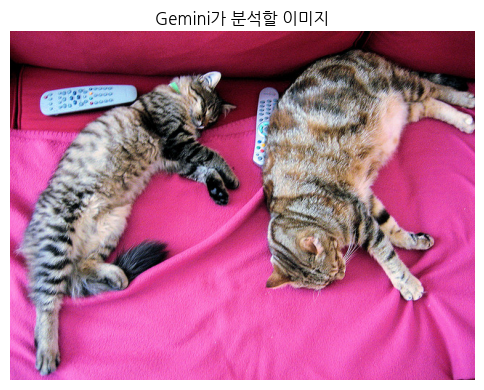

🖼️ Gemini의 이미지 분석

👤 Q: 이 이미지를 한국어로 자세히 설명해주세요.
🌈 A: 이 이미지는 안락한 실내 공간에서 깊이 잠든 두 마리의 고양이들을 위에서 내려다본 모습입니다. 전체적으로 따뜻하고 평화로운 분위기를 자아냅니다.

**전반적인 배경:**
*   **소파와 담요:** 사진의 배경은 붉은색 또는 진홍색의 소파로 보이며, 그 위에 밝은 분홍색의 부드러워 보이는 담요(또는 이불)가 넓게 깔려 있습니다. 담요는 주름이 약간 잡혀 있어 포근한 질감을 느낄 수 있습니다.

**왼쪽 고양이:**
*   **자세:** 이미지의 왼쪽 상단에 위치한 고양이는 담요 위에서 몸을 길게 뻗고 편안하게 잠들어 있습니다. 머리

👤 Q: 이 이미지의 분위기를 한 단어로 표현하면?
🌈 A: 이 이미지의 분위기를 한 단어로 표현하면 다음과 같습니다:

**평화로움**

(다른 후보: 나른함, 편안함)

👤 Q: 이 이미지에 대한 짧은 시를 써주세요.
🌈 A: 분홍빛 포근한 이불 위,
줄무늬 두 고양이 나란히 잠들었네.
리모컨도 잊은 채, 세상 시름 내려놓고
따스한 꿈 꾸는, 평화로운 오후.


In [26]:
# 🖼️ Gemini로 이미지 분석
from PIL import Image
import io

# 샘플 이미지 다운로드
def get_sample_image():
    sample_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
    response = requests.get(sample_url, timeout=10)
    return Image.open(io.BytesIO(response.content)).convert('RGB')

sample_img = get_sample_image()

# 이미지 보여주기
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(sample_img)
ax.set_title("Gemini가 분석할 이미지")
ax.axis('off')
plt.show()

# Gemini로 이미지 + 텍스트 처리
def gemini_analyze_image(image, prompt):
    """이미지와 함께 질문"""
    if not GEMINI_AVAILABLE:
        return "[시뮬레이션] 이 이미지에는 두 마리의 고양이가 침대 위에 누워있는 것이 보입니다. 매우 평화로운 분위기입니다."

    try:
        # Gemini는 이미지 + 텍스트를 함께 전달 가능
        response = gemini_model.generate_content([prompt, image])
        return response.text
    except Exception as e:
        return f"❌ 오류: {e}"

# 다양한 질문으로 테스트
prompts = [
    "이 이미지를 한국어로 자세히 설명해주세요.",
    "이 이미지의 분위기를 한 단어로 표현하면?",
    "이 이미지에 대한 짧은 시를 써주세요.",
]

print("🖼️ Gemini의 이미지 분석")
print("=" * 70)
for prompt in prompts:
    print(f"\n👤 Q: {prompt}")
    answer = gemini_analyze_image(sample_img, prompt)
    print(f"🌈 A: {answer[:300]}")

## 🎯 빈칸 채우기 실습 #2

Claude와 Gemini의 강점을 살린 코드를 작성해보세요!

In [27]:
# 🎯 실습 #2: Claude로 코드 작성, Gemini로 이미지 분석

# === Part A: Claude로 Python 코드 작성 ===
# Claude는 코딩 능력이 강하니까!
code_request = "Python으로 피보나치 수열의 10번째 값을 구하는 함수를 작성해주세요."

# TODO: 1. Claude 호출 (system prompt로 '코드만 응답' 지시)
claude_system = "당신은 모바일 앱 개발자입니다. 설명 없이 코드만 응답하세요."

claude_response = chat_claude(
    messages=[{"role": "user", "content": code_request}],
    system=claude_system,
    temperature=0.2,  # 코드는 낮은 temperature (예: 0.2)
)

print("🎭 Claude의 코드 응답:")
print(claude_response['content'])
print("\n" + "=" * 60)

# === Part B: Gemini로 이미지 분석 ===
# TODO: 2. Gemini로 이미지 분석
image_question = "이 이미지를 봤을 때 떠오르는 단어 5개를 한국어로 알려주세요."

gemini_response = gemini_analyze_image(sample_img, image_question)

print("🌈 Gemini의 이미지 분석:")
print(gemini_response)

🎭 Claude의 코드 응답:
[시뮬레이션] 안녕하세요! 저는 Claude예요. 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.

🌈 Gemini의 이미지 분석:
이 이미지를 봤을 때 떠오르는 단어 5개입니다:

1.  **고양이** (Cat)
2.  **잠** (Sleep)
3.  **핑크** (Pink - 담요 색깔)
4.  **휴식** (Rest)
5.  **편안함** (Comfort/Ease)


<details>
<summary>🔑 정답 보기</summary>

```python
# Part A
claude_system = "당신은 시니어 Python 개발자입니다. 설명 없이 코드만 응답하세요."

claude_response = chat_claude(
    messages=[{"role": "user", "content": code_request}],
    system=claude_system,
    temperature=0.2,  # 코드는 결정적으로
)

# Part B
gemini_response = gemini_analyze_image(sample_img, image_question)
```

각 모델의 강점 활용:
- **Claude**: 코딩에서 SWE-bench 87.6%로 1등 → 코드 작업에 최적
- **Gemini**: 멀티모달 + 한국어 → 이미지 분석에 좋음

</details>

### ✅ 체크포인트 3 - Claude + Gemini 마스터!

🎉 두 모델 학습 완료! 배운 것:
- **Claude**: 긴 컨텍스트, 코딩 강함, system 별도 파라미터
- **Gemini**: 멀티모달, 1M 컨텍스트, chat 객체 자동 관리
- **API 패턴 비교**: 비슷하지만 디테일이 다름

다음은 **한국어 특화 모델** 차례! 🇰🇷

---
# 7️⃣ Solar (Upstage) 실습 ☀️

## 📖 Solar 모델 라인업 (2026 기준)

| 모델 | 출시 | 크기 | 특징 |
|------|------|------|------|
| **Solar Pro 2** | 2025 | 31B | 한국 유일 **Frontier 모델** |
| **Solar Mini** | 2024 | 10.7B | DUS 아키텍처 (효율적) |

## 🌟 Solar의 차별점

### 1️⃣ **한국 유일 Frontier 모델**
- UK Artificial Analysis 지수 등재
- "Intelligence vs. Cost to Run"에서 **1위** (Elon Musk가 발끈한 그 모델!)

### 2️⃣ **DUS (Depth Up-Scaling) 아키텍처**
- 기존 LLM의 레이어를 늘려서 효율적 스케일링
- 자체 개발 혁신 기술

### 3️⃣ **법률/금융/의료 등 전문 분야 강점**
- B2B 시장 타겟
- 정확도·신뢰성 중시

### 4️⃣ **OpenAI 호환 API**
- OpenAI SDK 그대로 사용 가능!
- 마이그레이션 쉬움

> 💡 **API 사용**: https://console.upstage.ai 에서 가입 (무료 크레딧 제공)

In [28]:
# ☀️ Solar API 호출 (OpenAI 호환 방식)
def chat_solar(messages, model="solar-pro", temperature=0.7, max_tokens=500):
    """Solar API 호출 (OpenAI 호환)"""
    if not UPSTAGE_KEY:
        # 시뮬레이션
        return {
            'content': "[시뮬레이션] 안녕하세요! 저는 Upstage의 Solar입니다. "                        "API 키를 설정하면 진짜 응답을 받을 수 있어요.",
            'usage': {'input_tokens': 30, 'output_tokens': 20}
        }

    # Solar는 OpenAI 호환 API
    url = "https://api.upstage.ai/v1/solar/chat/completions"
    headers = {
        "Authorization": f"Bearer {UPSTAGE_KEY}",
        "Content-Type": "application/json"
    }
    payload = {
        "model": model,
        "messages": messages,
        "temperature": temperature,
        "max_tokens": max_tokens,
    }

    try:
        response = requests.post(url, json=payload, headers=headers, timeout=30)
        data = response.json()
        return {
            'content': data['choices'][0]['message']['content'],
            'usage': data.get('usage', {}),
        }
    except Exception as e:
        return {'content': f"❌ 오류: {e}", 'usage': None}

# 🎯 Solar 첫 호출
result = chat_solar([
    {"role": "user", "content": "안녕! 너에 대해 한 문장으로 소개해줘."}
])

print(f"☀️ Solar: {result['content']}")

☀️ Solar: 안녕하세요! 저는 업스테이지의 30.9B 파라미터 대규모 언어 모델인 **Solar Pro 2**입니다.  

(🤖 *한 문장으로 다시: "저는 업스테이지의 30.9B 파라미터 대규모 언어 모델 Solar Pro 2입니다."*)  

궁금한 점이 있다면 언제든 물어보세요! 😊


In [29]:
# 🌟 Solar의 강점: 한국어 전문 분야

# 법률/금융/의료 같은 전문 분야 질문
expert_questions = [
    {
        "분야": "법률",
        "system": "당신은 한국 법률 전문가입니다. 정확하고 신중하게 답해주세요.",
        "question": "전세 보증금을 못 돌려받을 때 법적으로 어떤 절차를 밟아야 하나요?"
    },
    {
        "분야": "금융",
        "system": "당신은 한국 금융 전문가입니다.",
        "question": "ISA 계좌와 일반 주식 계좌의 세제 혜택 차이를 설명해주세요."
    },
    {
        "분야": "의료",
        "system": "당신은 의학 정보를 제공하는 어시스턴트입니다. 전문 의료 조언은 실제 의사와 상담을 권하세요.",
        "question": "고혈압 환자가 식단에서 특히 주의해야 할 점이 무엇인가요?"
    },
]

print("☀️ Solar의 전문 분야 테스트")
print("=" * 70)

for item in expert_questions:
    result = chat_solar([
        {"role": "system", "content": item["system"]},
        {"role": "user", "content": item["question"]}
    ], temperature=0.3, max_tokens=400)

    print(f"\n📂 [{item['분야']}] {item['question']}")
    print(f"☀️ A: {result['content']}")
    print("-" * 70)

☀️ Solar의 전문 분야 테스트

📂 [법률] 전세 보증금을 못 돌려받을 때 법적으로 어떤 절차를 밟아야 하나요?
☀️ A: 전세 보증금을 돌려받지 못할 경우, 다음과 같은 **법적 절차**를 단계적으로 진행할 수 있습니다. 각 단계에서 필요한 서류와 법적 근거를 반드시 확인하시기 바랍니다.

---

### 1. **임대인과 직접 협상 (최우선)**
   - **내용증명우편** 발송:  
     보증금 반환을 요구하는 내용증명우편을 보내 공식적으로 의사를 통지합니다. (「민법」 제543조)  
     *예시: "○○년 ○월 ○일까지 보증금을 반환하지 않을 경우 법적 조치를 취하겠다"는 내용 포함.*

   - **협상 시 유의사항**:  
     - 대화 내용을 녹음하거나 문자/이메일 등 증거를 확보합니다.  
     - 임대인이 경제적 어려움을 호소할 경우, 분할 상환 약정을 체결할 수 있으나 반드시 **서면**으로 작성합니다.

---

### 2. **전세권 설정 여부 확인**
   - **전세권 등기**가 되어 있는 경우:  
     - 「민법」 제303조에 따라 **전세권 실행**을 통해 우선변제권을 행사할 수 있습니다.  
     - 법원에 **경매 신청**을 하여 보증금 회수가 가능합니다.  
     - *단, 경매 비용(감정료, 소송비용 등)이 발생할 수 있으므로 경제적 타당성을 검토해야 합니다.*

   - **전세권 미등기**인 경우:  
     - 일반 채권자로서 「주택임대차보호법」에 따른 우선변제권(최대 3년 분)을 주장할 수 있으나, 경매 시 후순위일 수 있습니다.

---

### 3. **지급명령 신청 (간이 절차)**
   - **소액사건처리법** 적용:  
     보증금 2억 원 이하인 경우, **지급명령**을 신청해 빠르게 해결할 수 있습니다.  
     - 관할 법원(임대인 주소지)에 신청서 제출 → 2주 내 결정.  
     - 임대인이 2주 내 **이의제기**를 하지 않으면 **확정판결과 동일한 효

## 🎯 빈칸 채우기 실습 #3

EXAONE과 Solar를 한국어 작업에 활용해보세요!

In [31]:
# 🎯 실습 #3: 한국어 모델 비교
# 같은 한국어 질문을 EXAONE과 Solar에 던지고 비교

korean_question = "한국의 '한(恨)' 정서를 외국인 친구에게 어떻게 설명할 수 있을까요?"

# TODO: 1. EXAONE으로 응답 받기
# print("🇰🇷 EXAONE 응답:")
# exaone_answer = chat_exaone(korean_question, max_new_tokens=300)
# print(exaone_answer)
# print()

# TODO: 2. Solar로 응답 받기
print("☀️ Solar 응답:")
solar_result = chat_solar([
    {"role": "user", "content": korean_question}
], temperature=0.7, max_tokens=300)
print(solar_result['content'])

print("\n💡 두 모델의 차이점을 비교해보세요!")

☀️ Solar 응답:
한국의 '한(恨)'은 깊은 슬픔, 아쉬움, 억울함, 미련 등이 복합적으로 어우러진 독특한 정서로, 단순히 '한탄'이나 '원한'으로 번역하기엔 미묘한 차이가 있습니다. 외국인 친구에게 다음과 같이 설명하면 이해하기 쉬울 거예요:

---

### 1. **"역사적 상처와 집단적 기억"**  
   - 예를 들어, 일제 강점기, 한국전쟁, 분단의 아픔 등 한국 역사에서 반복해 겪은 **억울한 상황**이 쌓이며 형성된 감정이라고 비유하세요.  
   - *"한국은 오랜 시간 외세의 침략과 가난을 겪으며 마음속에 풀리지 않는 응어리가 생겼어. '한'은 그 아픔을 잊지 않으면서도 삶을 견디게 하는 힘이기도 해."*  

### 2. **"개인적 서사와 예술적 표현"**  
   - 한국 예술(판소리, 민요, 영화 〈박하사탕〉 등)에서 자주 등장하는 주제로, **극단적인 감정 기복**이나 **비극적 운명**에 대한 집착을 설명하세요.  
   - *"한국 드라마나 영화에서 주인공이 갑자기 울분을 터뜨리거나 과거에 집착하는 모습은 '한'이 표출된 거야. 상처가 치유되지 않고 마음속에 남아있기 때문이지."*  

### 3. **"감정의 이중성: 슬픔과 끈기"**  
   - '한'은 절망만이 아닌, **극복하려는 의지**도 내포합니다.  
   - *"'한'은 슬픔이지만, 그 감정을 에너지로 바꿔 춤(살풀이춤), 음악(트로트), 심지어 경제 발전의 원동력이 되기도 했어."*  

### 4.

💡 두 모델의 차이점을 비교해보세요!


<details>
<summary>🔑 정답 보기</summary>

```python
exaone_answer = chat_exaone(korean_question, max_new_tokens=300)

solar_result = chat_solar([
    {"role": "user", "content": korean_question}
], temperature=0.7, max_tokens=300)
```

비교 포인트:
- 응답 스타일 (간결 vs 자세함)
- 문화적 정확성
- 한국어 자연스러움
- 응답 시간 (로컬 vs API)

</details>

## 🧠 퀴즈 #3

한국어 작업에서 ChatGPT 대신 EXAONE이나 Solar를 고려해야 하는 이유는?

- A) 더 저렴해서
- B) **한국 문화·언어에 특화 + 데이터 주권**
- C) 더 빨라서
- D) 모두 무료라서

<details>
<summary>👉 정답 보기</summary>

**B) 한국 문화·언어에 특화 + 데이터 주권**

이유:
- **언어**: 한국어 미묘한 뉘앙스, 존댓말, 한자어 처리 우수
- **문화**: 한국 역사·관습·정서 학습 데이터 풍부
- **데이터 주권**: 민감한 한국 데이터를 해외 서버로 안 보내도 됨
- **법적 컴플라이언스**: 개인정보보호법 등 한국 규정 준수

A는 부분적으로 맞음 (EXAONE 오픈웨이트는 무료 자체호스팅 가능)
C는 모델/인프라마다 다름
D는 EXAONE만 무료 (Solar는 API)

</details>

### ✅ 체크포인트 4 - 한국 LLM 마스터!

🎉 한국어 특화 모델 학습 완료! 배운 것:
- **EXAONE**: 오픈웨이트, 무료, 로컬 실행, 하이브리드 추론
- **Solar**: 한국 유일 Frontier, OpenAI 호환 API, 전문 분야 강점
- **한국어 작업**의 모델 선택 기준

다음은 **5개 모델 동시 비교** 실험! 🔬

---
# 8️⃣ 5개 모델 동시 비교 🔬

## 🎯 같은 질문, 다른 모델

5개 모델에 **동일한 질문** 던지고 응답 스타일·품질 비교!

In [32]:
# 🔬 5개 모델 통합 호출 함수
def ask_all_models(question, system="You are a helpful assistant.", max_tokens=300):
    """5개 모델에 같은 질문을 던지고 모든 응답 수집"""
    results = {}

    # 1. ChatGPT
    print("🤖 ChatGPT 응답 받는 중...", end=' ')
    start = time.time()
    r = chat_openai(
        [{"role": "system", "content": system},
         {"role": "user", "content": question}],
        temperature=0.7, max_tokens=max_tokens
    )
    results['ChatGPT'] = {
        'content': r['content'],
        'time': time.time() - start
    }
    print(f"✓ ({results['ChatGPT']['time']:.1f}s)")

    # 2. Claude
    print("🎭 Claude 응답 받는 중...", end=' ')
    start = time.time()
    r = chat_claude(
        [{"role": "user", "content": question}],
        system=system, temperature=0.7, max_tokens=max_tokens
    )
    results['Claude'] = {
        'content': r['content'],
        'time': time.time() - start
    }
    print(f"✓ ({results['Claude']['time']:.1f}s)")

    # 3. Gemini
    print("🌈 Gemini 응답 받는 중...", end=' ')
    start = time.time()
    # Gemini는 system + user를 합쳐서 prompt로
    combined_prompt = f"[System: {system}]\n\n{question}"
    r = chat_gemini(combined_prompt, temperature=0.7, max_tokens=max_tokens)
    results['Gemini'] = {
        'content': r['content'],
        'time': time.time() - start
    }
    print(f"✓ ({results['Gemini']['time']:.1f}s)")


    # 5. Solar
    print("☀️ Solar 응답 받는 중...", end=' ')
    start = time.time()
    r = chat_solar(
        [{"role": "system", "content": system},
         {"role": "user", "content": question}],
        temperature=0.7, max_tokens=max_tokens
    )
    results['Solar'] = {
        'content': r['content'],
        'time': time.time() - start
    }
    print(f"✓ ({results['Solar']['time']:.1f}s)")

    return results

print("✅ 비교 함수 준비 완료!")

✅ 비교 함수 준비 완료!


In [33]:
# 🔬 비교 실험 1: 한국어 질문
korean_question = "한국 음식 중에서 외국인들이 가장 좋아할만한 음식 3가지를 추천하고, 각 음식의 특징을 설명해주세요."

print("=" * 80)
print(f"🔍 질문: {korean_question}")
print("=" * 80)

results = ask_all_models(
    korean_question,
    system="당신은 한국 음식에 대해 잘 아는 친절한 안내자입니다.",
    max_tokens=350
)

# 결과 표시
icons = {'ChatGPT': '🤖', 'Claude': '🎭', 'Gemini': '🌈', 'Solar': '☀️'}

print("\n\n" + "=" * 80)
print("📋 응답 비교")
print("=" * 80)
for model_name, data in results.items():
    print(f"\n{icons[model_name]} === {model_name} (응답 시간: {data['time']:.1f}s) ===")
    print(data['content'][:500])
    print("-" * 80)

🔍 질문: 한국 음식 중에서 외국인들이 가장 좋아할만한 음식 3가지를 추천하고, 각 음식의 특징을 설명해주세요.
🤖 ChatGPT 응답 받는 중... ✓ (0.0s)
🎭 Claude 응답 받는 중... ✓ (0.0s)
🌈 Gemini 응답 받는 중... ✓ (3.2s)
☀️ Solar 응답 받는 중... ✓ (3.0s)


📋 응답 비교

🤖 === ChatGPT (응답 시간: 0.0s) ===
[시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.
--------------------------------------------------------------------------------

🎭 === Claude (응답 시간: 0.0s) ===
[시뮬레이션] 안녕하세요! 저는 Claude예요. 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.
--------------------------------------------------------------------------------

🌈 === Gemini (응답 시간: 3.2s) ===
안녕하세요! 한국 음식에 대해 궁금해하시는군요. 제가 한국 음
--------------------------------------------------------------------------------

☀️ === Solar (응답 시간: 3.0s) ===
한국 음식 중에서 외국인들이 특히 좋아하는 대표적인 3가지를 특징과 함께 소개해 드릴게요!  

### 1. **불고기 (Bulgogi)**  
- **특징**: 달콤한 양념에 재운 얇게 썬 소고기를 구워 먹는 요리로, 부드럽고 풍미가 뛰어납니다.  
- **인기 이유**:  
  - 고기 자체가 익숙한 재료이며, 달콤한 간장 베이스의 양념이 부담스럽지 않아 접근성이 좋습니다.  
  - 팬에 구워 먹거나 상추쌈과 함께 먹는 방식이 재미있습니다.  
- **추천 포인트**: 한국식 BBQ 레스토랑에서 직접 구워 먹을 수 있어

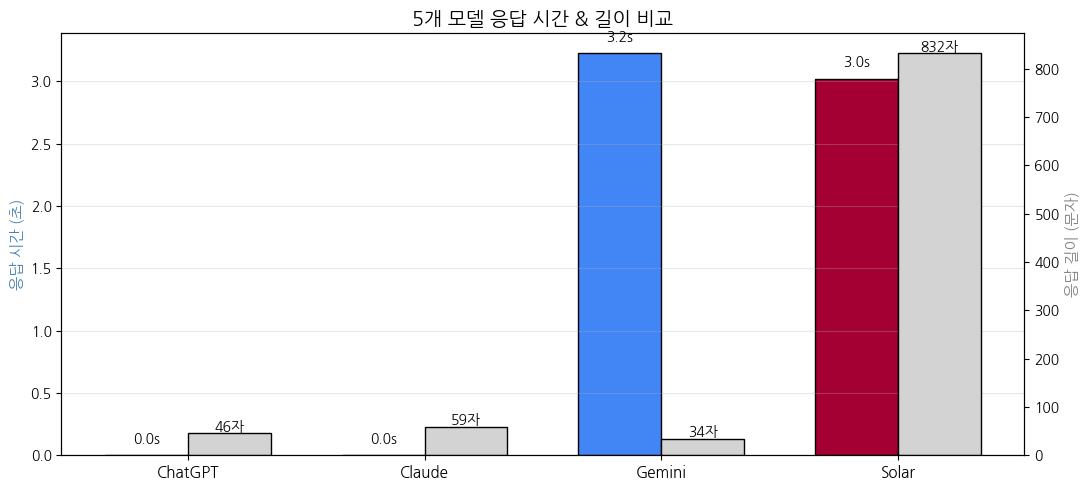


📊 관찰 포인트:
   • API 모델 vs 로컬 모델 (EXAONE)의 속도 차이
   • 같은 질문에 응답 길이도 모델마다 다름
   • 한국어 응답 품질 (EXAONE/Solar 강점)


In [34]:
# 🎨 응답 시간 비교 시각화
fig, ax = plt.subplots(figsize=(11, 5))

models = list(results.keys())
times = [results[m]['time'] for m in models]
content_lengths = [len(results[m]['content']) for m in models]

# 색상
colors = ['#10A37F', '#D97757', '#4285F4', '#A50034', '#FFD54F']

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, times, width, label='응답 시간 (초)',
               color=colors, edgecolor='black')
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, content_lengths, width, label='응답 길이 (문자)',
                color='lightgray', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('응답 시간 (초)', fontsize=11, color='steelblue')
ax2.set_ylabel('응답 길이 (문자)', fontsize=11, color='gray')
ax.set_title('5개 모델 응답 시간 & 길이 비교', fontsize=14, fontweight='bold')

# 값 표시
for bar, t in zip(bars1, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{t:.1f}s', ha='center', fontsize=10, fontweight='bold')
for bar, l in zip(bars2, content_lengths):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{l}자', ha='center', fontsize=10)

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n📊 관찰 포인트:")
print("   • API 모델 vs 로컬 모델 (EXAONE)의 속도 차이")
print("   • 같은 질문에 응답 길이도 모델마다 다름")
print("   • 한국어 응답 품질 (EXAONE/Solar 강점)")

## 🎯 모델별 응답 특성 정리

각 모델은 **고유한 응답 스타일**이 있어요:

| 모델 | 응답 스타일 | 주력 강점 |
|------|----------|----------|
| 🤖 **ChatGPT** | 구조화·중립적 | 범용성, 생태계 |
| 🎭 **Claude** | 상세하고 정확 | 코딩, 분석, 안전성 |
| 🌈 **Gemini** | 빠르고 구조적 | 멀티모달, 무료 |
| 🇰🇷 **EXAONE** | 한국 문화 친화 | 한국어, 무료 자체호스팅 |
| ☀️ **Solar** | 한국어 + 전문성 | 한국 비즈니스 |

---
# 9️⃣ 실전 활용 패턴 💼

> **"LLM을 단순 채팅 이상으로 활용하는 4가지 패턴"**

## 패턴 ① RAG (Retrieval-Augmented Generation)

> **"내 문서에서 답변 찾기"**

### 작동 흐름
```
사용자 질문
    ↓
[1] 임베딩으로 관련 문서 검색
    ↓
[2] 검색된 내용 + 질문을 LLM에 전달
    ↓
[3] LLM이 검색 결과 기반으로 답변
```

### 활용
- 기업 내부 문서 챗봇
- 법률·의료 자료 검색
- 코드베이스 Q&A

In [35]:
# 💼 패턴 ① 간단한 RAG 구현
class SimpleRAG:
    """간단한 RAG 시스템 (실제론 vector DB 사용)"""

    def __init__(self):
        # 가짜 지식 베이스
        self.documents = {
            "doc1": "회사 휴가 정책: 정규 직원은 연 15일 유급 휴가, 입사 1년 미만은 월 1일 지급.",
            "doc2": "원격 근무 정책: 주 3일 이상 출근 권장, 사전 승인 후 100% 원격 가능.",
            "doc3": "교육 지원: 직무 관련 교육비 연 200만원, 도서 구입비 월 5만원 지원.",
            "doc4": "병가 정책: 진단서 첨부 시 무제한 병가, 단순 컨디션 불량은 연 5일.",
        }

    def retrieve(self, query, top_k=2):
        """키워드 기반 검색 (실제론 임베딩 사용)"""
        # 키워드 매칭 (간단화)
        scored = []
        for doc_id, content in self.documents.items():
            score = sum(1 for word in query.split() if word in content)
            scored.append((doc_id, content, score))

        scored.sort(key=lambda x: -x[2])
        return scored[:top_k]

    def generate(self, query):
        """검색 + 생성"""
        # 1. 검색
        retrieved = self.retrieve(query)
        context = "\n".join([f"[{d_id}] {content}" for d_id, content, _ in retrieved])

        # 2. LLM에 전달
        prompt = (
            "다음 회사 정책 문서를 참고해서 질문에 답해주세요. "
            "문서에 없는 내용은 '문서에 없음'이라고 답하세요.\n\n"
            f"[참고 문서]\n{context}\n\n"
            f"[질문] {query}"
        )

        return chat_openai(
            [{"role": "user", "content": prompt}],
            temperature=0.3  # 사실 기반은 낮게
        )

# 시연
rag = SimpleRAG()

print("💼 패턴 ① RAG 시연")
print("=" * 70)

questions = [
    "휴가는 몇 일이나 받을 수 있나요?",
    "원격 근무할 수 있어요?",
    "스시 만드는 법 알려주세요",  # DB에 없는 질문
]

for q in questions:
    print(f"\n👤 Q: {q}")
    result = rag.generate(q)
    print(f"🤖 A: {result['content']}")

💼 패턴 ① RAG 시연

👤 Q: 휴가는 몇 일이나 받을 수 있나요?
🤖 A: [시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.

👤 Q: 원격 근무할 수 있어요?
🤖 A: [시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.

👤 Q: 스시 만드는 법 알려주세요
🤖 A: [시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.


## 패턴 ② Few-shot Prompting

> **"몇 가지 예시를 보여주고 패턴을 따르게 하기"**

### 활용
- 특정 형식으로 출력 (JSON, 표 등)
- 특정 스타일 모방
- 분류 작업

In [36]:
# 💼 패턴 ② Few-shot Prompting
def classify_with_examples(text):
    """감정 분류 (예시 기반)"""

    prompt = '''다음 한국어 문장을 긍정/중립/부정으로 분류하세요.

예시:
문장: "이 영화 정말 최고였어요! 강추!"
분류: 긍정

문장: "오늘 회의가 있어서 출근했어요."
분류: 중립

문장: "서비스가 너무 별로네요. 환불 요청합니다."
분류: 부정

문장: "그냥 그래요. 특별할 것 없어요."
분류: 중립

이제 다음 문장을 분류하세요. 결과만 한 단어로 답하세요.
문장: "''' + text + '''"
분류:'''

    result = chat_openai(
        [{"role": "user", "content": prompt}],
        temperature=0.1,  # 분류는 결정적으로
        max_tokens=20
    )
    return result['content'].strip()

# 테스트
test_sentences = [
    "오늘 회사에서 좋은 소식 들었어요!",
    "맛집이라더니 평범하네요.",
    "그냥 평범한 하루였어요.",
    "정말 최악의 경험이었습니다. 다시는 안 갈래요.",
    "새로운 도전이 기다리고 있어요!",
]

print("💼 Few-shot 감정 분류")
print("=" * 60)
for sentence in test_sentences:
    classification = classify_with_examples(sentence)
    print(f"📝 '{sentence}'")
    print(f"   → {classification}\n")

💼 Few-shot 감정 분류
📝 '오늘 회사에서 좋은 소식 들었어요!'
   → [시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.

📝 '맛집이라더니 평범하네요.'
   → [시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.

📝 '그냥 평범한 하루였어요.'
   → [시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.

📝 '정말 최악의 경험이었습니다. 다시는 안 갈래요.'
   → [시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.

📝 '새로운 도전이 기다리고 있어요!'
   → [시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.



## 패턴 ③ Chain-of-Thought (CoT)

> **"생각의 흐름을 단계별로 작성하게 하기 → 정확도 ↑"**

### 작동 원리
- "단계별로 생각해봐"라는 한 마디로 정확도 향상
- 수학·논리·복잡한 추론 작업에 효과적

### 예시 비교
**일반**: "242 × 17 = ?"
- ❌ "잘 모르겠습니다" 또는 잘못된 답

**CoT**: "242 × 17을 단계별로 계산해보자"
- ✅ 200×17=3400, 42×17=714, 3400+714=4114

In [37]:
# 💼 패턴 ③ Chain-of-Thought
math_problem = "한 농부가 닭과 토끼를 합쳐서 35마리를 키우고 있습니다. 이들의 다리를 모두 세어보니 94개였습니다. 닭과 토끼는 각각 몇 마리일까요?"

# 일반 프롬프트
print("❌ 일반 프롬프트:")
result_normal = chat_openai(
    [{"role": "user", "content": math_problem + " 답만 알려주세요."}],
    temperature=0.0
)
print(result_normal['content'])

print("\n" + "=" * 60)

# CoT 프롬프트
print("✅ CoT 프롬프트 (단계별 사고):")
cot_prompt = math_problem + "\n\n단계별로 천천히 생각해보고, 각 단계를 명확히 보여주세요."

result_cot = chat_openai(
    [{"role": "user", "content": cot_prompt}],
    temperature=0.0,
    max_tokens=500
)
print(result_cot['content'])

print("\n💡 CoT는 복잡한 추론에서 정확도를 크게 높여줍니다!")

❌ 일반 프롬프트:
[시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.

✅ CoT 프롬프트 (단계별 사고):
[시뮬레이션] 안녕하세요! 실제 API 키를 설정하면 진짜 응답을 받을 수 있어요.

💡 CoT는 복잡한 추론에서 정확도를 크게 높여줍니다!


## 패턴 ④ Agent (도구 + 추론)

> **"LLM이 도구들을 자율적으로 조합해서 작업 수행"**

### 기본 아이디어
- 사용자 요청을 LLM이 받음
- 필요한 도구들을 차례로 호출
- 결과를 종합해서 최종 응답

### ReAct 패턴: Reason + Act
```
Thought: 사용자가 날씨를 물었네. weather 도구 호출 필요.
Action: get_weather(city="서울")
Observation: {temp: 12, condition: "맑음"}
Thought: 옷차림 조언도 추가하자.
Action: 응답 작성
Final: 서울은 12도 맑음. 가벼운 자켓 추천!
```

In [ ]:
# 💼 패턴 ④ 간단한 Agent (의사 코드)
class SimpleAgent:
    """여러 도구를 활용하는 간단한 에이전트"""

    def __init__(self):
        self.tools = {
            'get_weather': get_weather,
            'calculate': calculate,
        }

    def run(self, user_request):
        """Agent의 핵심 흐름 (실제론 더 복잡)"""
        print(f"🤖 Agent 시작")
        print(f"👤 요청: {user_request}\n")

        # 1. LLM에게 계획 요청
        plan_prompt = (
            f"사용자 요청: {user_request}\n\n"
            "사용 가능한 도구: get_weather(city), calculate(expression)\n\n"
            "이 요청을 수행하기 위해 어떤 도구를 어떤 순서로 사용해야 할까요? "
            "간단한 계획만 제시하세요."
        )

        plan = chat_openai(
            [{"role": "user", "content": plan_prompt}],
            temperature=0.3, max_tokens=200
        )

        print(f"🧠 Agent의 계획:")
        print(plan['content'])
        print("\n" + "=" * 60)

        # 2. 실제 도구 호출 (실전에선 LLM이 자동 결정)
        # 여기선 시뮬레이션
        print("\n🔧 도구 실행 시뮬레이션:")
        if '날씨' in user_request or 'weather' in user_request.lower():
            for city in ['서울', '부산']:
                if city in user_request:
                    result = get_weather(city)
                    print(f"   get_weather({city}): {result}")

        if any(c in user_request for c in ['+', '-', '*', '/', '계산']):
            print("   calculate(...)을 호출할 거예요")

        # 3. 최종 응답
        print("\n✨ Agent가 모든 도구 결과를 종합해서 최종 응답 생성")

# 시연
agent = SimpleAgent()
agent.run("서울과 부산의 날씨를 비교해서 어디가 옷을 따뜻하게 입어야 할지 알려줘")

---
# 🔟 비용 분석 + 최적화 💰

## 💰 모델별 가격 비교 (2026 5월 기준)

| 모델 | 입력 (1M 토큰) | 출력 (1M 토큰) | 특이사항 |
|------|--------------|--------------|----------|
| **GPT-5.5** | $1.75 | $14.00 | OpenAI 플래그십 |
| **GPT-5.2** | 더 저렴 | 더 저렴 | 일반 용도 |
| **Claude Opus 4.7** | $5 | $25 | 코딩 최강 |
| **Claude Haiku 4** | $0.25 | $1.25 | 매우 저렴 |
| **Gemini 3.1 Pro** | ~$1.25 | ~$10 | 1M 컨텍스트 |
| **Gemini 3 Flash** | 매우 저렴 | 매우 저렴 | 무료 등급 있음 |
| **Solar Pro** | $0.50 | $1.50 | 한국 모델 |
| **EXAONE** | 무료* | 무료* | *자체 호스팅 |

> ⚠️ 가격은 빠르게 변동. 각 콘솔에서 최신 가격 확인 필수

In [38]:
from dataclasses import dataclass  # ← 이 한 줄 추가!

# 💰 비용 계산기
@dataclass
class LLMCostCalculator:
    """LLM 비용 계산"""

    # (입력 가격, 출력 가격) per 1M 토큰
    pricing = {
        'GPT-5.5':            (1.75, 14.00),
        'GPT-5.2':            (0.50, 4.00),
        'Claude Opus 4.7':    (5.00, 25.00),
        'Claude Sonnet 4.7':  (3.00, 15.00),
        'Claude Haiku 4':     (0.25, 1.25),
        'Gemini 3.1 Pro':     (1.25, 10.00),
        'Gemini 3 Flash':     (0.075, 0.30),
        'Solar Pro':          (0.50, 1.50),
        'EXAONE (self-host)': (0.0, 0.0),  # GPU 비용은 별도
    }

    def cost(self, model, input_tokens, output_tokens):
        """단일 요청 비용"""
        in_price, out_price = self.pricing[model]
        return (input_tokens * in_price + output_tokens * out_price) / 1_000_000

    def monthly_cost(self, model, daily_requests, avg_in=500, avg_out=200):
        """월간 비용"""
        per_request = self.cost(model, avg_in, avg_out)
        return per_request * daily_requests * 30, per_request

calc = LLMCostCalculator()

# 시나리오: 일 10,000건 챗봇
daily = 10_000
avg_input = 500
avg_output = 200

print(f"💰 일 {daily:,}건 챗봇 운영 시 월간 비용")
print(f"   (평균 입력 {avg_input}토큰, 출력 {avg_output}토큰)")
print("=" * 70)

scenarios = []
for model in calc.pricing.keys():
    monthly, per_req = calc.monthly_cost(model, daily, avg_input, avg_output)
    scenarios.append((model, per_req, monthly))

# 정렬 (저렴한 순)
scenarios.sort(key=lambda x: x[2])

print(f"\n{'모델':<22s} {'건당':>12s} {'월 비용':>15s}")
print("-" * 70)
for model, per_req, monthly in scenarios:
    print(f"{model:<22s} ${per_req:>10.6f} ${monthly:>14,.2f}")

💰 일 10,000건 챗봇 운영 시 월간 비용
   (평균 입력 500토큰, 출력 200토큰)

모델                               건당            월 비용
----------------------------------------------------------------------
EXAONE (self-host)     $  0.000000 $          0.00
Gemini 3 Flash         $  0.000097 $         29.25
Claude Haiku 4         $  0.000375 $        112.50
Solar Pro              $  0.000550 $        165.00
GPT-5.2                $  0.001050 $        315.00
Gemini 3.1 Pro         $  0.002625 $        787.50
GPT-5.5                $  0.003675 $      1,102.50
Claude Sonnet 4.7      $  0.004500 $      1,350.00
Claude Opus 4.7        $  0.007500 $      2,250.00


In [39]:
# 🎨 월 비용 비교 시각화
fig, ax = plt.subplots(figsize=(13, 6))

models = [s[0] for s in scenarios]
monthly_costs = [s[2] for s in scenarios]

colors = ['#34D399' if c < 100 else ('#FCD34D' if c < 1000 else '#F87171')
          for c in monthly_costs]

ax.barh(models, monthly_costs, color=colors, edgecolor='black')
ax.set_xlabel('월 비용 ($) - 일 10,000건 기준', fontsize=12)
ax.set_title('LLM 모델별 월간 비용 비교 (저렴한 순)',
             fontsize=14, fontweight='bold')
ax.set_xscale('log')

# 값 표시
for i, (model, _, cost) in enumerate(scenarios):
    if cost < 1:
        label = f'${cost:.2f}'
    elif cost < 1000:
        label = f'${cost:.0f}'
    else:
        label = f'${cost/1000:.1f}K'
    ax.text(cost*1.1, i, label, va='center', fontsize=10, fontweight='bold')

# 범례
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#34D399', label='저렴 (<$100/월)'),
    Patch(facecolor='#FCD34D', label='보통 ($100~1000)'),
    Patch(facecolor='#F87171', label='비쌈 ($1000+)'),
]
ax.legend(handles=legend_elements, loc='lower right')

ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n💡 인사이트:")
print(f"   • 최저비용 ({scenarios[0][0]}): ${scenarios[0][2]:.2f}/월")
print(f"   • 최고비용 ({scenarios[-1][0]}): ${scenarios[-1][2]:.2f}/월")
print(f"   • 차이: {scenarios[-1][2]/max(scenarios[0][2], 0.01):.0f}배")
print("\n💡 단순 작업에 GPT-5.5 vs Claude Haiku → 비용 50배 차이!")

/tmp/ipykernel_6429/314737151.py:37: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()



💡 인사이트:
   • 최저비용 (EXAONE (self-host)): $0.00/월
   • 최고비용 (Claude Opus 4.7): $2250.00/월
   • 차이: 225000배

💡 단순 작업에 GPT-5.5 vs Claude Haiku → 비용 50배 차이!


## 💡 비용 절감 5가지 팁

### 1️⃣ **작업에 맞는 모델 선택**
- 단순 분류 → Haiku, Flash (저렴)
- 어려운 추론 → Opus, GPT-5.5 (비쌈)

### 2️⃣ **Prompt 최적화**
- 짧고 명확한 프롬프트
- "한 단어로 답해" 같은 제약
- max_tokens 제한

### 3️⃣ **캐싱**
- 같은 질문에 같은 답 → DB에 저장
- 자주 묻는 질문 반복 호출 방지

### 4️⃣ **Prompt Caching (Claude)**
- 같은 system prompt나 긴 컨텍스트 재사용 시 90% 할인
- "system prompt + 사용자 질문"이 반복되는 챗봇에 유용

### 5️⃣ **자체호스팅 검토**
- 일 100만 건 이상 → 자체호스팅 검토
- EXAONE, Llama 등 오픈 모델 + GPU

---
# 🎓 최종 정리

## 🌟 우리가 배운 것

### 🤖 5가지 LLM 모델

| 모델 | 핵심 |
|------|------|
| **ChatGPT (OpenAI)** | 범용, 생태계 풍부, function calling |
| **Claude (Anthropic)** | 코딩 최강, 긴 컨텍스트, 안전성 |
| **Gemini (Google)** | 네이티브 멀티모달, 1M 컨텍스트, 무료 등급 |
| **EXAONE (LG)** | 한국어, 오픈웨이트, 무료 자체호스팅 |
| **Solar (Upstage)** | 한국 Frontier, 전문 분야 |

### 🔧 API 사용 패턴

| 기능 | 학습한 것 |
|------|----------|
| 기본 호출 | messages, temperature, max_tokens |
| System Prompt | 역할/규칙 부여 |
| 멀티턴 대화 | 전체 히스토리 관리 |
| Streaming | 실시간 출력 |
| Function Calling | 외부 도구 활용 |
| Multi-modal | 이미지+텍스트 (Gemini) |

### 💼 실전 패턴 4가지
1. **RAG**: 검색 + 생성
2. **Few-shot**: 예시로 패턴 학습
3. **Chain-of-Thought**: 단계별 사고로 정확도 ↑
4. **Agent**: 도구 자율 조합

### 💰 비용 최적화
- 모델별 50배 차이 → 작업에 맞게 선택
- Prompt 최적화, 캐싱, 자체호스팅 검토

## 🎯 실전 선택 황금 규칙

### 어떤 모델을 골라야 할까?

```
1. 한국어가 중요한가?
   ├── YES + 데이터 주권 → EXAONE 또는 Solar
   └── NO → 다음

2. 어떤 작업?
   ├── 코딩 → Claude Opus 4.7
   ├── 일반 챗봇 → GPT-5.5 / Claude Sonnet
   ├── 멀티모달 (이미지/비디오) → Gemini 3.1 Pro
   └── 추론 (수학·논리) → o1 / GPT-Rosalind / EXAONE Deep

3. 비용 제약?
   ├── 매우 제한 → Claude Haiku / Gemini Flash
   ├── 보통 → 적정 가격대 모델
   └── 무제한 → 최고 모델

4. 일일 처리량?
   ├── 100만+ 건 → 자체호스팅 검토 (EXAONE)
   └── 그 이하 → API
```

## 🚀 다음 단계

### 📚 더 깊이 공부할 주제
- **Prompt Engineering** 패턴
- **RAG** with Vector DB (Pinecone, Weaviate)
- **LangChain, LlamaIndex** 같은 프레임워크
- **Agent** 빌드 (CrewAI, AutoGen)
- **Fine-tuning** (OpenAI, Claude 등에서 가능)

### 💡 실전 프로젝트 아이디어
- 🎓 **AI 학습 도우미**: 교과서 PDF + RAG
- 💼 **고객 응답 자동화**: FAQ + Function Calling
- 🌏 **다국어 번역기**: 한국어 → 5개국 (Gemini)
- 🇰🇷 **한국 법률 챗봇**: Solar + 법률 DB
- 📊 **데이터 분석 자동화**: Claude + Code Interpreter

## 🏆 시리즈 완주 축하합니다!

전체 8개 노트북 시리즈를 마무리하셨네요!

| # | 노트북 | 주제 |
|---|--------|------|
| 1 | Transformer | 🧠 모든 LLM의 기반 |
| 2 | BERT | 📖 텍스트 이해 |
| 3 | GPT | ✍️ 텍스트 생성 |
| 4 | VLM 전반 | 🌐 멀티모달 개요 |
| 5 | CLIP 깊이 | 🔗 매칭 마스터 |
| 6 | 생성형 VLM 깊이 | 💬 생성 마스터 |
| 7 | 시나리오 매트릭스 | 🎯 선택의 지혜 |
| 8 | **상업용 LLM 실습** | 🌐 **API 활용** ⭐ |

## 💡 마지막 조언

> 🎯 **"이론과 실전을 모두 갖춘 AI 엔지니어가 되었습니다!"**

여러분은 이제:
- ✅ AI의 핵심 원리를 이해합니다
- ✅ 다양한 모델을 비교·선택할 수 있습니다
- ✅ API와 자체호스팅을 자유롭게 다룹니다
- ✅ 실전 시스템을 설계할 수 있습니다

### 🌟 앞으로의 학습 방향

```
지금까지: 기초 이론 + 단일 모델 사용
   ↓
다음 단계: 통합 시스템 + 운영
   ├── LangChain / LlamaIndex 학습
   ├── Vector DB로 RAG 구축
   ├── Agent 프레임워크
   ├── 프로덕션 배포 (Docker, K8s)
   └── 모니터링 + 비용 관리
```

## 🙏 감사합니다!

8개의 노트북, 수많은 코드와 시각화를 함께해주셔서 감사합니다.

> "The best way to learn AI is to build with it."
>
> "AI를 배우는 가장 좋은 방법은 직접 만들어보는 것."

**Happy AI Engineering! 🚀✨🌐**
